# Validación del Sistema de Automatización MLOps

Análisis de rendimiento, escalabilidad y robustez del sistema de ejecución paralela de pipelines MLOps.

**Convención de nombres:** `vX_YUVW`
| Campo | Significado |
|-------|-------------|
| X | Número de fase (del proyecto) |
| Y | Número de experimento (1-4) |
| U | Runner de origen (1=Local, 2=GHA, 3=K8s-8gb, 4=K8s-24gb, 5=ESP32) |
| VW | Número secuencial de variante (01-99) |


## 0. Carga de datos y configuración

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import numpy as np
from datetime import datetime, timedelta

# Configuración visual
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Paleta de colores por runner
RUNNER_COLORS = {
    "Local":              "#636EFA",
    "GithubActions":      "#EF553B",
    "K8s-8gb":            "#00CC96",
    "K8s-24gb":           "#AB63FA",
    "ESP32-self-hosted":  "#FFA15A",
}

RUNNER_ORDER = ["Local", "GithubActions", "K8s-8gb", "K8s-24gb", "ESP32-self-hosted"]


In [2]:
# ── Carga del dataset ──
# Reemplazar por la ruta real cuando se tengan los datos del experimento
CSV_PATH = "ejemplo.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["created_at", "started_at", "completed_at"])

# Validación rápida
print(f"Total registros: {len(df)}")
print(f"Experimentos: {sorted(df['experiment'].unique())}")
print(f"Runners: {df['runner'].unique()}")
print(f"Fases: {df['phase'].unique()}")
print()
df.head(10)


Total registros: 46
Experimentos: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Runners: <StringArray>
['Local', 'GithubActions', 'K8s-8gb', 'K8s-24gb', 'ESP32-self-hosted']
Length: 5, dtype: str
Fases: <StringArray>
[ 'f03_windows', 'f05_modeling',   'f07_modval',   'f08_sysval',
  'f01_explore',   'f02_events',  'f04_targets']
Length: 7, dtype: str



,experiment,variant,phase,runner,runner_code,parent_variant,created_at,started_at,completed_at,queue_seconds,execution_seconds,total_seconds,status
0,1,v3_1101,f03_windows,Local,1,NaN,2026-06-15 09:00:00,2026-06-15 09:00:00,2026-06-15 09:00:50,0,50,50,success
1,1,v5_1101,f05_modeling,Local,1,NaN,2026-06-15 09:00:00,2026-06-15 09:00:00,2026-06-15 09:11:47,0,707,707,success
2,1,v3_1201,f03_windows,GithubActions,2,NaN,2026-06-15 09:00:00,2026-06-15 09:00:02,2026-06-15 09:01:11,2,69,71,success
3,1,v5_1201,f05_modeling,GithubActions,2,NaN,2026-06-15 09:00:00,2026-06-15 09:00:02,2026-06-15 09:08:57,2,535,537,success
4,1,v3_1301,f03_windows,K8s-8gb,3,NaN,2026-06-15 09:00:00,2026-06-15 09:00:03,2026-06-15 09:00:55,3,52,55,success
5,1,v5_1301,f05_modeling,K8s-8gb,3,NaN,2026-06-15 09:00:00,2026-06-15 09:00:03,2026-06-15 09:06:49,3,406,409,success
6,1,v3_1401,f03_windows,K8s-24gb,4,NaN,2026-06-15 09:00:00,2026-06-15 09:00:07,2026-06-15 09:00:50,7,43,50,success
7,1,v5_1401,f05_modeling,K8s-24gb,4,NaN,2026-06-15 09:00:00,2026-06-15 09:00:07,2026-06-15 09:05:52,7,345,352,success
8,2,v3_2301,f03_windows,K8s-8gb,3,NaN,2026-06-15 10:00:00,2026-06-15 10:00:09,2026-06-15 10:01:30,9,81,90,success
9,2,v3_2302,f03_windows,K8s-8gb,3,NaN,2026-06-15 10:00:00,2026-06-15 10:00:03,2026-06-15 10:01:25,3,82,85,success


In [3]:
# ── Vista por experimento ──
for exp_id in sorted(df["experiment"].unique()):
    subset = df[df["experiment"] == exp_id]
    print(f"\n{'='*60}")
    print(f"Experimento {exp_id}: {len(subset)} registros")
    print(f"  Fases:   {subset['phase'].unique().tolist()}")
    print(f"  Runners: {subset['runner'].unique().tolist()}")
    print(f"  Variantes: {subset['variant'].unique().tolist()}")



Experimento 1: 8 registros
  Fases:   ['f03_windows', 'f05_modeling']
  Runners: ['Local', 'GithubActions', 'K8s-8gb', 'K8s-24gb']
  Variantes: ['v3_1101', 'v5_1101', 'v3_1201', 'v5_1201', 'v3_1301', 'v5_1301', 'v3_1401', 'v5_1401']

Experimento 2: 8 registros
  Fases:   ['f03_windows']
  Runners: ['K8s-8gb']
  Variantes: ['v3_2301', 'v3_2302', 'v3_2303', 'v3_2304', 'v3_2305', 'v3_2306', 'v3_2307', 'v3_2308']

Experimento 3: 4 registros
  Fases:   ['f07_modval', 'f08_sysval']
  Runners: ['ESP32-self-hosted', 'K8s-8gb']
  Variantes: ['v7_3501', 'v7_3301', 'v8_3501', 'v8_3301']

Experimento 4: 26 registros
  Fases:   ['f01_explore', 'f02_events', 'f03_windows', 'f04_targets']
  Runners: ['Local', 'K8s-8gb']
  Variantes: ['v1_4101', 'v2_4101', 'v2_4102', 'v3_4101', 'v3_4102', 'v3_4103', 'v3_4104', 'v4_4101', 'v4_4102', 'v4_4103', 'v4_4104', 'v4_4105', 'v4_4106', 'v1_4301', 'v2_4301', 'v2_4302', 'v3_4301', 'v3_4302', 'v3_4303', 'v3_4304', 'v4_4301', 'v4_4302', 'v4_4303', 'v4_4304', 'v4_43

---
## 1. Eficiencia de Recursos — ¿Merece la pena escalar?

**Objetivo:** Evaluar el impacto del hardware en el tiempo de ejecución de una fase individual.

**Diseño:** Se ejecutan dos fases (una ligera, `f03_windows`, y una pesada, `f05_modeling`) con los mismos parámetros en todos los runners cloud/local.

**Gráfica:** Barras agrupadas — eje X: fase, eje Y: tiempo, cada barra: un runner.


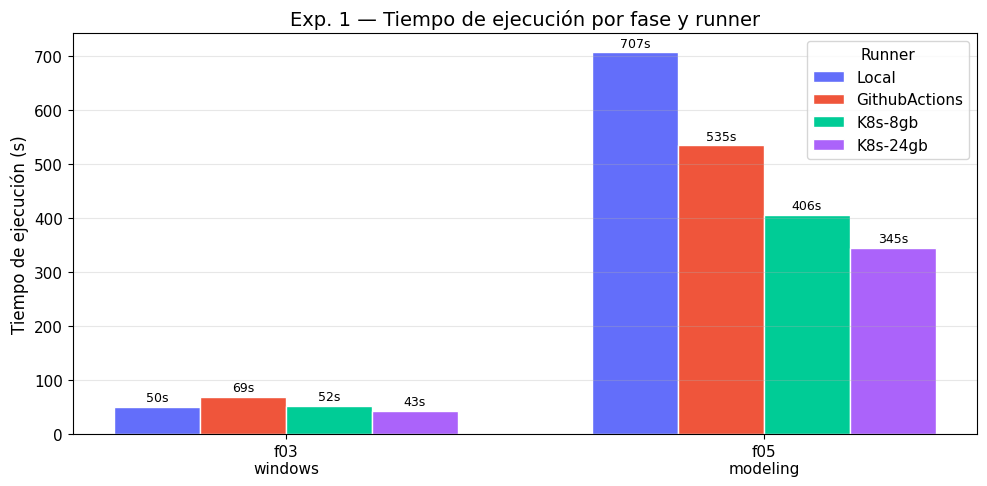

In [4]:
# ── Experimento 1: Eficiencia de Recursos ──
df1 = df[df["experiment"] == 1].copy()

phases = df1["phase"].unique()
runners = [r for r in RUNNER_ORDER if r in df1["runner"].unique()]

fig, ax = plt.subplots(figsize=(10, 5))

n_phases = len(phases)
n_runners = len(runners)
bar_width = 0.18
x = np.arange(n_phases)

for i, runner in enumerate(runners):
    times = []
    for phase in phases:
        mask = (df1["phase"] == phase) & (df1["runner"] == runner)
        val = df1.loc[mask, "execution_seconds"].values
        times.append(val[0] if len(val) > 0 else 0)
    offset = (i - n_runners / 2 + 0.5) * bar_width
    bars = ax.bar(x + offset, times, bar_width,
                  label=runner, color=RUNNER_COLORS[runner], edgecolor="white")
    # Etiquetas de tiempo sobre cada barra
    for bar, t in zip(bars, times):
        if t > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    f"{t:.0f}s", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels([p.replace("_", "\n") for p in phases])
ax.set_ylabel("Tiempo de ejecución (s)")
ax.set_title("Exp. 1 — Tiempo de ejecución por fase y runner")
ax.legend(title="Runner")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Análisis

> **Espacio para conclusiones.** Comparar los tiempos entre runners. ¿Compensa K8s-24gb frente a K8s-8gb considerando que permite 3 pods vs 5? Calcular el *throughput efectivo* (variantes/hora) para cada runner.


---
## 2. Saturación y Colas de Espera — Estrés del Sistema

**Objetivo:** Verificar que el sistema gestiona correctamente ráfagas de ejecuciones que superan `max-parallel`.

**Diseño:** 8 variantes de `f03_windows` lanzadas simultáneamente en `K8s-8gb` (max-parallel=5). Las 5 primeras deben arrancar inmediatamente; las 3 restantes deben quedar en cola.

**Gráfica:** Timeline horizontal diferenciando tiempo en cola vs. ejecución activa.


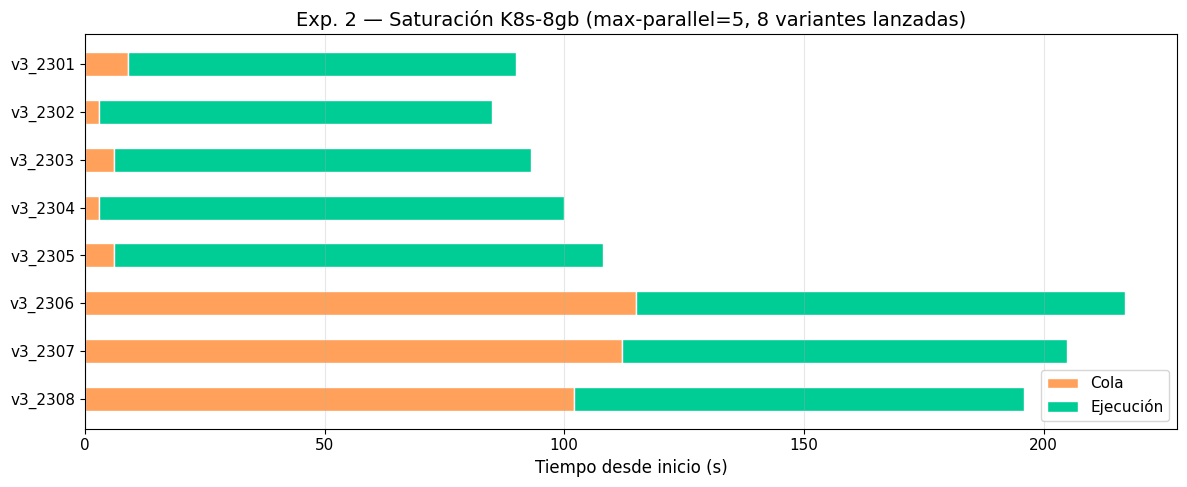


Resumen de tiempos:
variant  queue_seconds  execution_seconds  total_seconds
v3_2301              9                 81             90
v3_2302              3                 82             85
v3_2303              6                 87             93
v3_2304              3                 97            100
v3_2305              6                102            108
v3_2306            115                102            217
v3_2307            112                 93            205
v3_2308            102                 94            196


In [5]:
# ── Experimento 2: Saturación y Colas ──
df2 = df[df["experiment"] == 2].copy().sort_values("created_at")

# Calcular offsets relativos al primer created_at
t0 = df2["created_at"].min()
df2["queue_start"] = (df2["created_at"] - t0).dt.total_seconds()
df2["exec_start"]  = (df2["started_at"] - t0).dt.total_seconds()
df2["exec_end"]    = (df2["completed_at"] - t0).dt.total_seconds()

fig, ax = plt.subplots(figsize=(12, 5))

y_labels = df2["variant"].tolist()
y_pos = range(len(y_labels))

for i, (_, row) in enumerate(df2.iterrows()):
    # Barra de cola (naranja)
    queue_duration = row["exec_start"] - row["queue_start"]
    if queue_duration > 0:
        ax.barh(i, queue_duration, left=row["queue_start"],
                height=0.5, color="#FFA15A", edgecolor="white", label="Cola" if i == 0 else "")
    # Barra de ejecución (verde)
    exec_duration = row["exec_end"] - row["exec_start"]
    ax.barh(i, exec_duration, left=row["exec_start"],
            height=0.5, color="#00CC96", edgecolor="white", label="Ejecución" if i == 0 else "")

# Línea de max-parallel
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)

ax.set_yticks(list(y_pos))
ax.set_yticklabels(y_labels)
ax.set_xlabel("Tiempo desde inicio (s)")
ax.set_title("Exp. 2 — Saturación K8s-8gb (max-parallel=5, 8 variantes lanzadas)")
ax.invert_yaxis()

# Leyenda sin duplicados
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc="lower right")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# Tabla resumen
print("\nResumen de tiempos:")
print(df2[["variant", "queue_seconds", "execution_seconds", "total_seconds"]].to_string(index=False))


### Análisis

> **Espacio para conclusiones.** Verificar que las variantes 6-8 muestran un tiempo en cola ≈ al tiempo de ejecución de las primeras 5. Confirmar que no hay fallos ni corrupción de datos. Calcular la utilización media del clúster.


---
## 3. Validación Virtual vs. Real — Fases 7 y 8

**Objetivo:** Comparar la fidelidad del entorno virtualizado (K8s) frente al microcontrolador físico (ESP32).

**Diseño:** Ejecutar `f07_modval` y `f08_sysval` en ambos entornos con el mismo dataset (5000 filas).

**Nota:** En f07, el tiempo de compilación es lo que diferencia los entornos; el tiempo de inferencia está regulado por `MTI_MS`. La comparación debe separar ambos componentes.

**Gráfica:** Barras agrupadas comparando ESP32 vs. K8s para cada fase.


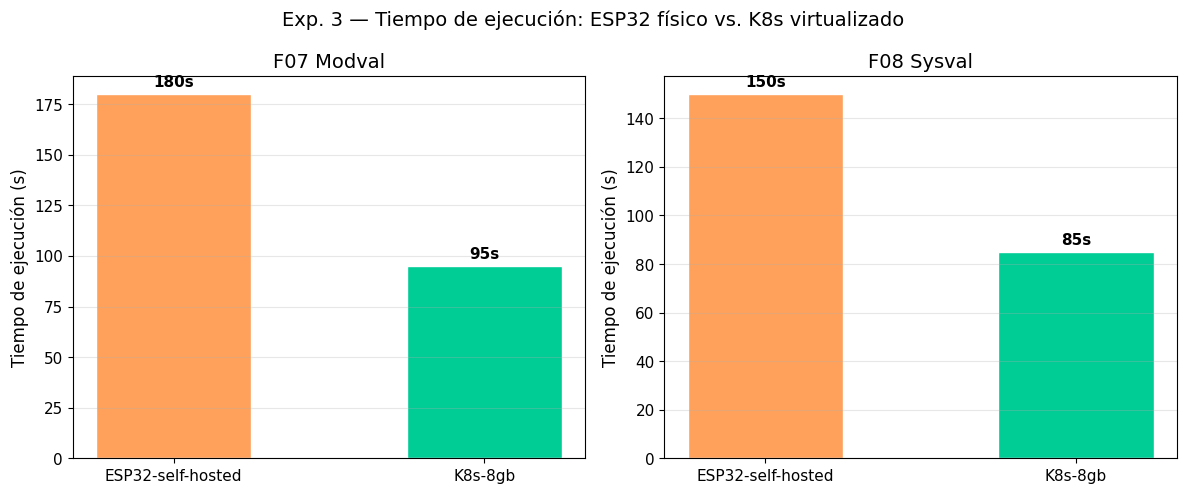


Ratio ESP32/K8s:
  f07_modval: 1.89x
  f08_sysval: 1.76x


In [6]:
# ── Experimento 3: Virtual vs. Real ──
df3 = df[df["experiment"] == 3].copy()

phases = ["f07_modval", "f08_sysval"]
runners_3 = ["ESP32-self-hosted", "K8s-8gb"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

for idx, phase in enumerate(phases):
    ax = axes[idx]
    subset = df3[df3["phase"] == phase]

    bars_data = []
    for runner in runners_3:
        row = subset[subset["runner"] == runner]
        if len(row) > 0:
            bars_data.append(row.iloc[0]["execution_seconds"])
        else:
            bars_data.append(0)

    colors = [RUNNER_COLORS[r] for r in runners_3]
    bars = ax.bar(runners_3, bars_data, color=colors, edgecolor="white", width=0.5)

    for bar, val in zip(bars, bars_data):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f"{val:.0f}s", ha="center", va="bottom", fontsize=11, fontweight="bold")

    ax.set_title(phase.replace("_", " ").title())
    ax.set_ylabel("Tiempo de ejecución (s)")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Exp. 3 — Tiempo de ejecución: ESP32 físico vs. K8s virtualizado", fontsize=14)
plt.tight_layout()
plt.show()

# Ratios
print("\nRatio ESP32/K8s:")
for phase in phases:
    esp = df3[(df3["phase"] == phase) & (df3["runner"] == "ESP32-self-hosted")]["execution_seconds"].values
    k8s = df3[(df3["phase"] == phase) & (df3["runner"] == "K8s-8gb")]["execution_seconds"].values
    if len(esp) > 0 and len(k8s) > 0:
        print(f"  {phase}: {esp[0]/k8s[0]:.2f}x")


### Análisis

> **Espacio para conclusiones.** ¿Los resultados de inferencia son idénticos? ¿El ratio de tiempo es constante o varía por fase? Si la fidelidad es alta, esto valida las pre-validaciones masivas en entornos virtualizados.


---
## 4. Valor de la Paralelización — Gantt de Ejecución

**Objetivo:** Cuantificar la reducción de Lead Time ejecutando variantes en paralelo frente a secuencial.

**Diseño del lote:**
```
f01 (1 variante)
 ├── f02-A ──┬── f03-A1 ── f04-A1a
 │           └── f03-A2 ── f04-A2a
 │                        └── f04-A2b
 └── f02-B ──┬── f03-B1 ── f04-B1a
              └── f03-B2 ── f04-B2a
                           └── f04-B2b
```

**Gráfica:** Diagrama de Gantt con dos paneles (secuencial vs. paralelo) + línea de camino crítico.


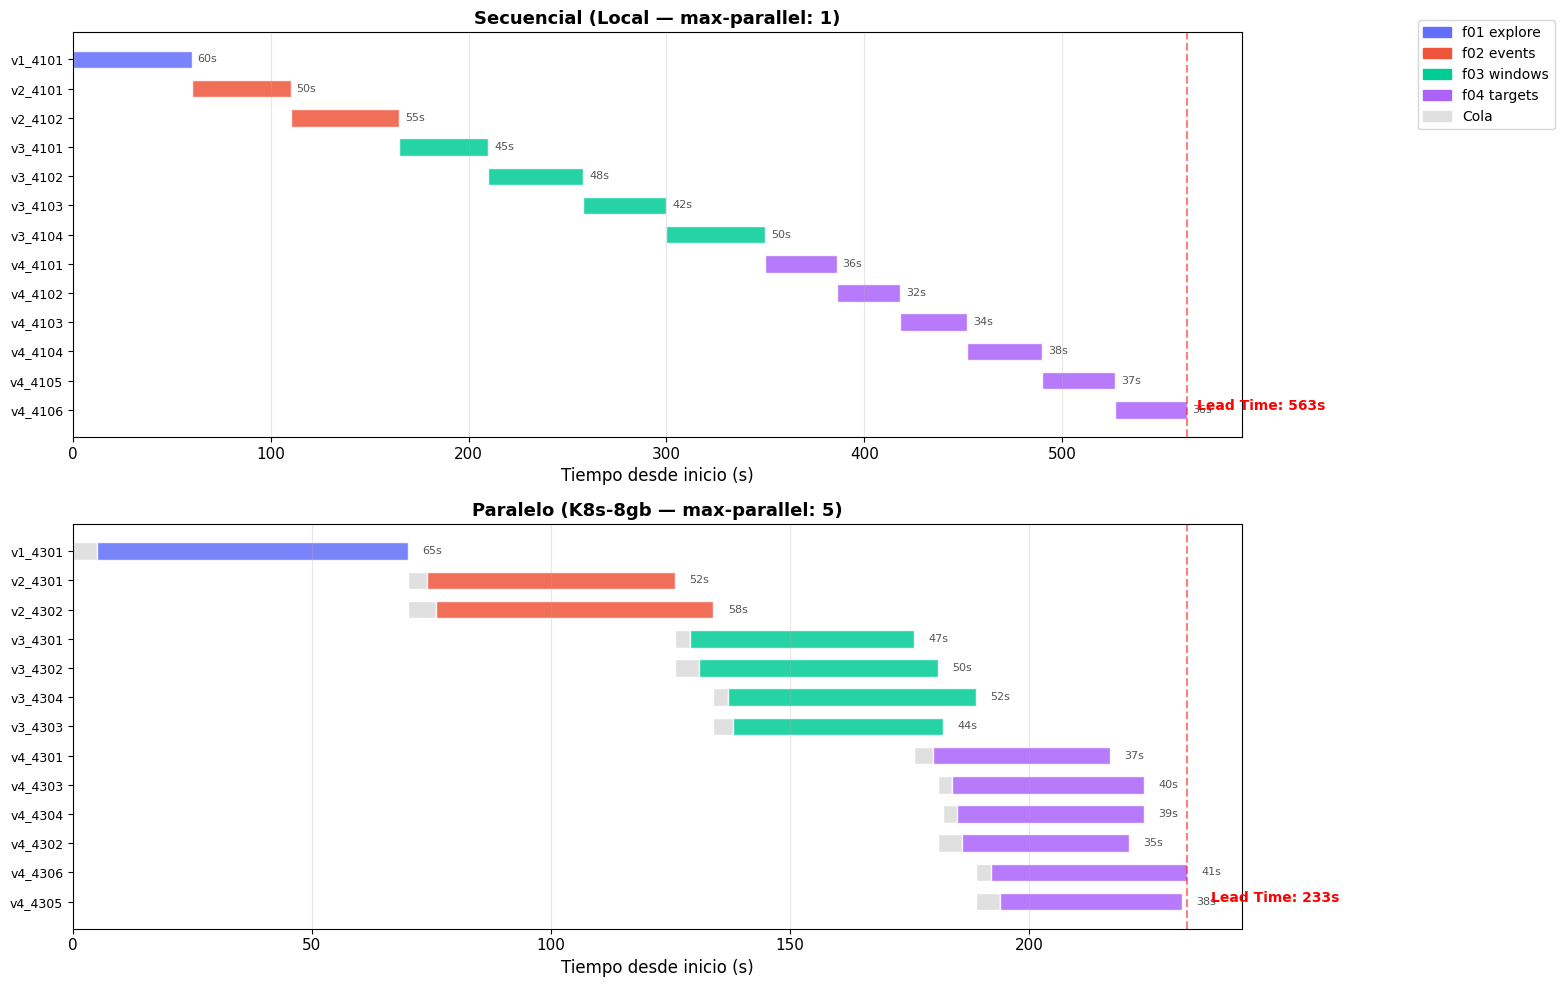


Lead Time Secuencial:  563s (9.4 min)
Lead Time Paralelo:    233s (3.9 min)
Speedup:               2.42x
Reducción:             58.6%


In [7]:
# ── Experimento 4: Gantt de Paralelización ──
df4 = df[df["experiment"] == 4].copy()

# Separar secuencial (Local) y paralelo (K8s-8gb)
df4_seq = df4[df4["runner"] == "Local"].copy().sort_values("started_at")
df4_par = df4[df4["runner"] == "K8s-8gb"].copy().sort_values("started_at")

# Colores por fase
PHASE_COLORS = {
    "f01_explore": "#636EFA",
    "f02_events":  "#EF553B",
    "f03_windows": "#00CC96",
    "f04_targets": "#AB63FA",
}

def plot_gantt(ax, data, title, show_critical=False):
    """Plot a Gantt chart for a set of variants."""
    t0 = data["created_at"].min()

    y_labels = data["variant"].tolist()

    for i, (_, row) in enumerate(data.iterrows()):
        start = (row["started_at"] - t0).total_seconds()
        duration = row["execution_seconds"]
        queue = (row["started_at"] - row["created_at"]).total_seconds()

        # Cola (gris claro)
        if queue > 1:
            q_start = (row["created_at"] - t0).total_seconds()
            ax.barh(i, queue, left=q_start, height=0.6,
                    color="#E0E0E0", edgecolor="white")

        # Ejecución (color por fase)
        color = PHASE_COLORS.get(row["phase"], "#999")
        ax.barh(i, duration, left=start, height=0.6,
                color=color, edgecolor="white", alpha=0.85)

        # Etiqueta de tiempo
        ax.text(start + duration + 3, i, f"{duration:.0f}s",
                va="center", fontsize=8, color="#555")

    ax.set_yticks(range(len(y_labels)))
    ax.set_yticklabels(y_labels, fontsize=9)
    ax.set_xlabel("Tiempo desde inicio (s)")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)

    # Lead time total
    total = (data["completed_at"].max() - t0).total_seconds()
    ax.axvline(x=total, color="red", linestyle="--", alpha=0.5)
    ax.text(total + 5, len(y_labels) - 1, f"Lead Time: {total:.0f}s",
            color="red", fontsize=10, fontweight="bold")

    return total


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

lt_seq = plot_gantt(ax1, df4_seq, "Secuencial (Local — max-parallel: 1)")
lt_par = plot_gantt(ax2, df4_par, "Paralelo (K8s-8gb — max-parallel: 5)")

# Leyenda compartida
legend_patches = [mpatches.Patch(color=c, label=p.replace("_", " "))
                  for p, c in PHASE_COLORS.items()]
legend_patches.append(mpatches.Patch(color="#E0E0E0", label="Cola"))
fig.legend(handles=legend_patches, loc="upper right", fontsize=10,
           bbox_to_anchor=(0.98, 0.98))

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# Métricas
speedup = lt_seq / lt_par if lt_par > 0 else float("inf")
print(f"\n{'='*50}")
print(f"Lead Time Secuencial:  {lt_seq:.0f}s ({lt_seq/60:.1f} min)")
print(f"Lead Time Paralelo:    {lt_par:.0f}s ({lt_par/60:.1f} min)")
print(f"Speedup:               {speedup:.2f}x")
print(f"Reducción:             {(1 - lt_par/lt_seq)*100:.1f}%")


In [8]:
# ── Camino Crítico (mínimo teórico) ──
# El camino crítico es la rama más larga de dependencias.
# Para calcularlo, recorremos el DAG de parent → child y sumamos tiempos.

def compute_critical_path(data):
    """Compute the critical path through the variant dependency DAG."""
    exec_map = dict(zip(data["variant"], data["execution_seconds"]))
    parent_map = dict(zip(data["variant"], data["parent_variant"]))
    queue_map = dict(zip(data["variant"], data["queue_seconds"]))

    def longest_path(variant):
        t = exec_map.get(variant, 0)
        parent = parent_map.get(variant, "")
        if parent and parent in exec_map:
            t += longest_path(parent)
        return t

    paths = {v: longest_path(v) for v in data["variant"]}
    critical_variant = max(paths, key=paths.get)
    critical_time = paths[critical_variant]

    # Reconstruct path
    path = []
    v = critical_variant
    while v and v in exec_map:
        path.append(v)
        v = parent_map.get(v, "")
    path.reverse()

    return critical_time, path

cp_time, cp_path = compute_critical_path(df4_par)

print(f"Camino Crítico (mínimo teórico): {cp_time:.0f}s ({cp_time/60:.1f} min)")
print(f"Ruta: {' → '.join(cp_path)}")
print(f"\nEficiencia del sistema paralelo: {cp_time/lt_par*100:.1f}% del óptimo teórico")
print(f"Eficiencia del sistema secuencial: {cp_time/lt_seq*100:.1f}% del óptimo teórico")


Camino Crítico (mínimo teórico): 216s (3.6 min)
Ruta: v1_4301 → v2_4302 → v3_4304 → v4_4306

Eficiencia del sistema paralelo: 92.7% del óptimo teórico
Eficiencia del sistema secuencial: 38.4% del óptimo teórico


### Análisis

> **Espacio para conclusiones.** Cuantificar el speedup y la eficiencia respecto al camino crítico. La frase clave: *"El sistema alcanza un Lead Time de X segundos, a un Y% del límite teórico impuesto por las dependencias del pipeline, frente al Z% que supone la ejecución secuencial."*


---
## Resumen y Cierre

> **TODO:** Tabla resumen / matriz de decisión consolidando los resultados de los 4 experimentos.
> Columnas: Runner × Velocidad relativa × Paralelismo × Coste/disponibilidad × Tipo de fase recomendado.


In [9]:
# ── Tabla resumen (placeholder) ──
summary = pd.DataFrame({
    "Runner": RUNNER_ORDER,
    "max-parallel": [1, 20, 5, 3, 1],
    "Mejor para": [
        "Baseline / debug",
        "Fases ligeras masivas (f01-f04)",
        "Balance paralelismo/recursos (f05)",
        "Fases con alta demanda de RAM",
        "Validación HW real (f07/f08)"
    ],
    "Limitaciones": [
        "Sin paralelismo",
        "Timeout 6h, recursos genéricos, cuota mensual",
        "Recursos compartidos del clúster",
        "Solo 3 pods concurrentes",
        "1 dispositivo físico"
    ]
})
print(summary.to_string(index=False))


           Runner  max-parallel                         Mejor para                                  Limitaciones
            Local             1                   Baseline / debug                               Sin paralelismo
    GithubActions            20    Fases ligeras masivas (f01-f04) Timeout 6h, recursos genéricos, cuota mensual
          K8s-8gb             5 Balance paralelismo/recursos (f05)              Recursos compartidos del clúster
         K8s-24gb             3      Fases con alta demanda de RAM                      Solo 3 pods concurrentes
ESP32-self-hosted             1       Validación HW real (f07/f08)                          1 dispositivo físico
